## 授權與來源（License & Attribution）

本課程自編與改編部分：Copyright 2026 leonjyentub；授權：Apache License 2.0（`../LICENSE`）。
上游：Aurélien Géron, `ageron/handson-mlp`（Apache-2.0），commit `47eba45aacc85feae51ba7db68dd1ca66cb25e0a`。
另一來源：`leonjyentub/MachineLearning2025`（課程作者自有程式；其程式另採 Apache-2.0）。
本檔修改聲明：取材與參考 handson-mlp Ch.5／Appendix C；整合 MachineLearning2025 決策樹、hinge loss 與 SVM kernel。 教學版本重新編排與精簡實驗、補充課堂說明及輸出，並非未修改的原始上游檔案。
完整來源對照與第三方授權：`../SOURCES.md`、`../THIRD_PARTY_NOTICES.md`。
上述 Apache-2.0 不延伸至未取得授權的資料、圖片或其他第三方素材；保留所有適用的原始署名。

# 06｜決策樹與SVM補充

對應 `slides/06_決策樹與SVM補充.md`。本檔由 `11_決策樹與SVM.ipynb` 改名，程式與已執行輸出保留。

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mlcourse.common import ROOT, DATA, OUT, SEED, FAST, setup, savefig, report, data_path
setup()

{'profile': 'fast',
 'seed': 42,
 'data': '/Users/leonjye/Documents/MacProject/MLCourse2026/programs/data'}

## 1. 一棵可閱讀的 Iris 決策樹

`export_text` 印出從根到葉的規則；葉節點的 `predict_proba` 來自到達該葉的訓練樣本比例。

|--- petal length (cm) <= 2.45
|   |--- class: 0
|--- petal length (cm) >  2.45
|   |--- petal width (cm) <= 1.55
|   |   |--- class: 1
|   |--- petal width (cm) >  1.55
|   |   |--- class: 2

leaf probabilities for first 2 test flowers:
[[0.    0.056 0.944]
 [0.    0.971 0.029]]


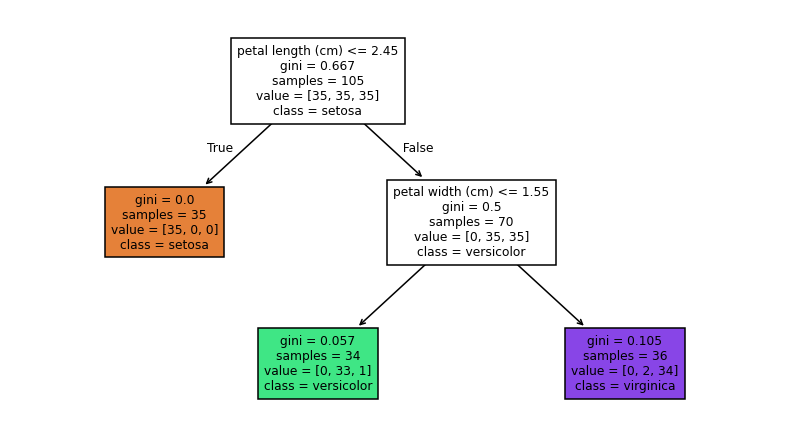

In [2]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
iris = load_iris()
Xtr, Xte, ytr, yte = train_test_split(iris.data, iris.target, test_size=.3, stratify=iris.target, random_state=SEED)
tree = DecisionTreeClassifier(max_depth=2, random_state=SEED).fit(Xtr, ytr)
print(export_text(tree, feature_names=list(iris.feature_names)))
print('leaf probabilities for first 2 test flowers:')
print(np.round(tree.predict_proba(Xte[:2]), 3))
fig, ax = plt.subplots(figsize=(9, 5))
plot_tree(tree, feature_names=iris.feature_names, class_names=list(iris.target_names), filled=True, ax=ax, fontsize=8)
savefig('11_iris_tree')

## 2. Gini 與 Entropy，以及投影片手算驗算

$\text{Gini}=1-\sum_k p_k^2$；$\text{Entropy}=-\sum_k p_k\log_2 p_k$。對應投影片活動「哪個節點比較純？」節點標籤數 `[4,0]`、`[2,2]`、`[3,1]`。

In [3]:
def gini(counts):
    p = np.asarray(counts, float); p = p / p.sum()
    return float(1 - np.sum(p ** 2))
def entropy(counts):
    p = np.asarray(counts, float); p = p / p.sum()
    p = p[p > 0]
    return float(-np.sum(p * np.log2(p)))

nodes = {'[4,0]': [4, 0], '[2,2]': [2, 2], '[3,1]': [3, 1]}
tbl = pd.DataFrame({'Gini': {k: gini(v) for k, v in nodes.items()},
                    'Entropy': {k: entropy(v) for k, v in nodes.items()}})
assert np.allclose(tbl.Gini, [0, .5, .375])
assert np.allclose(tbl.Entropy, [0, 1, 0.81127812])
tbl

,Gini,Entropy
"[4,0]",0.000,-0.000000
"[2,2]",0.500,1.000000
"[3,1]",0.375,0.811278


## 3. 手算一次分割：不能只比較左右平均

對應投影片活動「算一次分割」。父節點 `[4,4]`（8 筆），方案 A：左 `[3,0]`、右 `[1,4]`；方案 B：左 `[2,2]`、右 `[2,2]`。權重是樣本數比例。

In [4]:
def weighted_gini(left, right):
    nl, nr = sum(left), sum(right); n = nl + nr
    return nl / n * gini(left) + nr / n * gini(right)
parent = gini([4, 4])
A = weighted_gini([3, 0], [1, 4]); B = weighted_gini([2, 2], [2, 2])
assert np.isclose(parent, .5) and np.isclose(A, .2) and np.isclose(B, .5)
assert np.isclose(parent - A, .3) and np.isclose(parent - B, 0.0)
pd.Series({'parent_Gini': parent, 'planA_weighted_Gini': A, 'planA_drop': parent - A,
           'planB_weighted_Gini': B, 'planB_drop': parent - B})

parent_Gini            0.5
planA_weighted_Gini    0.2
planA_drop             0.3
planB_weighted_Gini    0.5
planB_drop             0.0
dtype: float64

## 4. 正則化：彎月資料上的邊界

不加限制的樹會把訓練點框得很細。`max_depth`、`min_samples_leaf` 等把有效複雜度壓低（教材圖 5-3）。

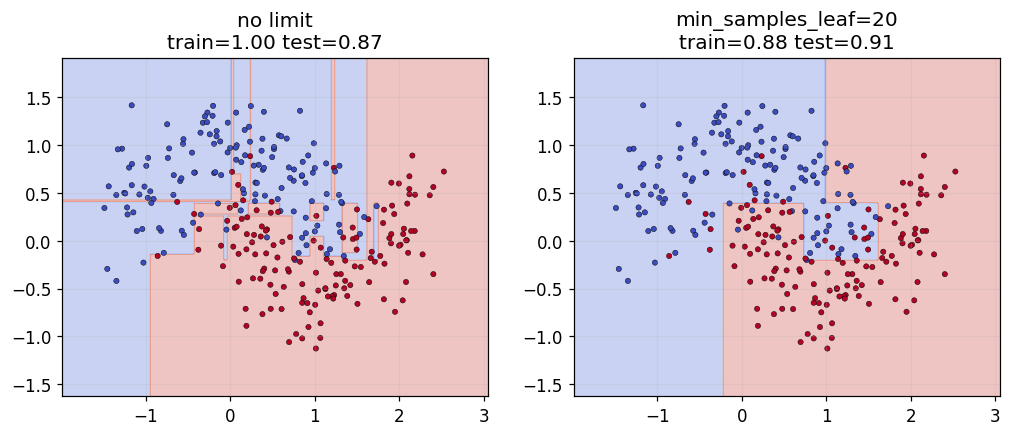

,depth,train_acc,test_acc
model,,,
no limit,11,1.000,0.866667
min_samples_leaf=20,5,0.875,0.908333


In [5]:
from sklearn.datasets import make_moons
Xm, ym = make_moons(n_samples=400, noise=.3, random_state=SEED)
Xmtr, Xmte, ymtr, ymte = train_test_split(Xm, ym, test_size=.3, random_state=SEED)
xx, yy = np.meshgrid(np.linspace(Xm[:, 0].min() - .5, Xm[:, 0].max() + .5, 300),
                     np.linspace(Xm[:, 1].min() - .5, Xm[:, 1].max() + .5, 300))
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
rows = []
for ax, kw, name in [(axes[0], {}, 'no limit'), (axes[1], {'min_samples_leaf': 20}, 'min_samples_leaf=20')]:
    t = DecisionTreeClassifier(random_state=SEED, **kw).fit(Xmtr, ymtr)
    zz = t.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, zz, alpha=.3, cmap='coolwarm')
    ax.scatter(Xmtr[:, 0], Xmtr[:, 1], c=ymtr, cmap='coolwarm', s=12, edgecolor='k', linewidth=.3)
    ax.set_title(f'{name}\ntrain={t.score(Xmtr, ymtr):.2f} test={t.score(Xmte, ymte):.2f}')
    rows.append({'model': name, 'depth': t.get_depth(), 'train_acc': t.score(Xmtr, ymtr), 'test_acc': t.score(Xmte, ymte)})
savefig('11_tree_regularization')
moons_reg = pd.DataFrame(rows).set_index('model')
assert moons_reg.loc['no limit', 'train_acc'] > moons_reg.loc['min_samples_leaf=20', 'train_acc']
moons_reg

## 5. 迴歸樹：葉節點輸出平均，因為平方損失

對應投影片活動「為什麼預測平均值？」葉內目標 `[1,2,6]`。

MSE by constant: {2: 5.667, 3: 4.667, 4: 5.667} -> best = mean = 3.0
MAE by constant: {2: 1.667, 3: 2.0, 4: 2.333} -> best = median = 2.0


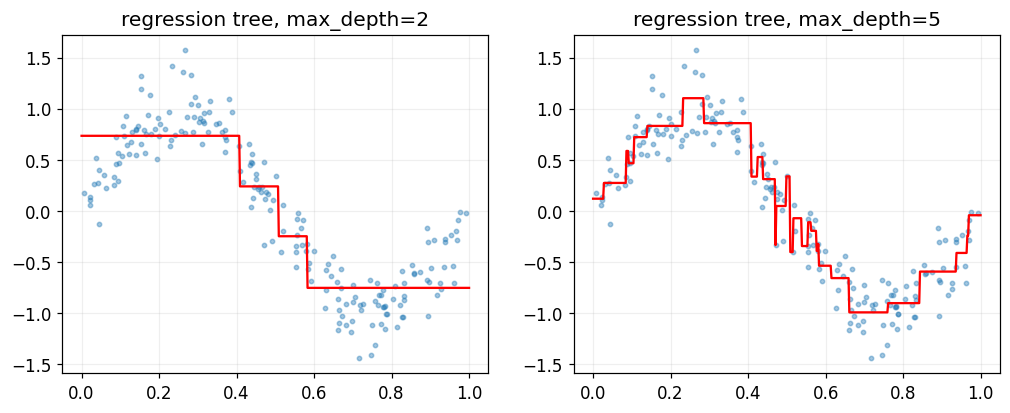

In [6]:
leaf = np.array([1., 2., 6.])
mse_of = {c: float(np.mean((leaf - c) ** 2)) for c in [2, 3, 4]}
mae_of = {c: float(np.mean(np.abs(leaf - c))) for c in [2, 3, 4]}
assert np.isclose(mse_of[3], 14 / 3) and mse_of[3] == min(mse_of.values())   # 平均使 MSE 最小
assert mae_of[2] == min(mae_of.values())                                     # 中位數使 MAE 最小
print('MSE by constant:', {k: round(v, 3) for k, v in mse_of.items()}, '-> best = mean =', leaf.mean())
print('MAE by constant:', {k: round(v, 3) for k, v in mae_of.items()}, '-> best = median =', np.median(leaf))

from sklearn.tree import DecisionTreeRegressor
rng = np.random.default_rng(SEED)
xr = np.sort(rng.uniform(0, 1, 200))[:, None]
yr = np.sin(2 * np.pi * xr[:, 0]) + rng.normal(0, .2, 200)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, d in zip(axes, [2, 5]):
    rt = DecisionTreeRegressor(max_depth=d, random_state=SEED).fit(xr, yr)
    g = np.linspace(0, 1, 500)[:, None]
    ax.scatter(xr, yr, s=8, alpha=.4); ax.plot(g, rt.predict(g), 'r-')
    ax.set_title(f'regression tree, max_depth={d}')
savefig('11_regression_tree')

## 6. 座標方向與不穩定性

樹只能做垂直於座標軸的切割。旋轉特徵（例如用 PCA）後，同一份資料可能用更少的分割就分開（教材圖 5-7～5-9）。

In [7]:
from sklearn.decomposition import PCA
rng = np.random.default_rng(SEED)
base = rng.uniform(-1, 1, (300, 2))
angle = np.deg2rad(30); R = np.array([[np.cos(angle), -np.sin(angle)], [np.sin(angle), np.cos(angle)]])
Xrot = base @ R.T
lab = (base[:, 0] > 0).astype(int)            # 真實邊界在旋轉前的座標軸上
depth_raw = DecisionTreeClassifier(random_state=SEED).fit(Xrot, lab).get_depth()
Xpca = PCA(n_components=2, random_state=SEED).fit_transform(Xrot)
depth_pca = DecisionTreeClassifier(random_state=SEED).fit(Xpca, lab).get_depth()
# 小幅改動訓練資料 -> 規則可能整組改變
d1 = DecisionTreeClassifier(max_depth=3, random_state=SEED).fit(Xrot, lab)
d2 = DecisionTreeClassifier(max_depth=3, random_state=SEED).fit(Xrot[:-8], lab[:-8])
assert depth_pca <= depth_raw
print('tree depth on rotated axes:', depth_raw, ' | after PCA rotation:', depth_pca)
print('root feature changed after dropping 8 rows:', d1.tree_.feature[0] != d2.tree_.feature[0]
      or not np.isclose(d1.tree_.threshold[0], d2.tree_.threshold[0]))

tree depth on rotated axes: 5  | after PCA rotation: 4
root feature changed after dropping 8 rows: True


## 7. 補充 SVM：軟間隔 C 與 RBF gamma

SVM 用「間隔」比較分隔面。軟間隔 `C` 越大越不容忍違規；RBF `gamma` 越大，每個支持向量影響範圍越小、邊界越彎（教材附錄 C）。

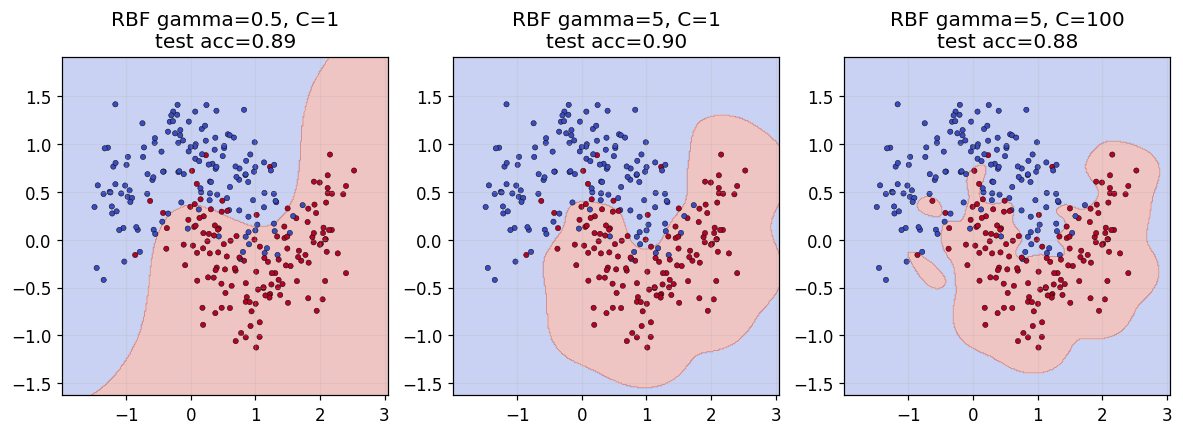

In [8]:
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (gamma, C) in zip(axes, [(0.5, 1), (5, 1), (5, 100)]):
    svm = make_pipeline(StandardScaler(), SVC(kernel='rbf', gamma=gamma, C=C)).fit(Xmtr, ymtr)
    zz = svm.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, zz, alpha=.3, cmap='coolwarm')
    ax.scatter(Xmtr[:, 0], Xmtr[:, 1], c=ymtr, cmap='coolwarm', s=12, edgecolor='k', linewidth=.3)
    ax.set_title(f'RBF gamma={gamma}, C={C}\ntest acc={svm.score(Xmte, ymte):.2f}')
savefig('11_svm_rbf')

## 8. 同一切分，三種模型的 CV 比較

樹深度 `[2,4,8,None]`、標準化 logistic、標準化 RBF SVM，用同一份 moons 訓練資料做 5 折 CV。

In [9]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
rows = []
for name, est in {'tree_d2': DecisionTreeClassifier(max_depth=2, random_state=SEED),
                  'tree_d4': DecisionTreeClassifier(max_depth=4, random_state=SEED),
                  'tree_d8': DecisionTreeClassifier(max_depth=8, random_state=SEED),
                  'tree_full': DecisionTreeClassifier(random_state=SEED),
                  'logistic_std': make_pipeline(StandardScaler(), LogisticRegression()),
                  'svm_rbf_std': make_pipeline(StandardScaler(), SVC(kernel='rbf', C=1))}.items():
    cv = cross_val_score(est, Xmtr, ymtr, cv=5)
    est.fit(Xmtr, ymtr)
    rows.append({'model': name, 'CV_accuracy': cv.mean(), 'CV_sd': cv.std(ddof=1), 'test_accuracy': est.score(Xmte, ymte)})
compare = pd.DataFrame(rows).set_index('model')
report('trees_svm', {'gini_entropy_check': tbl.to_dict(), 'split_gain': {'A_drop': .3, 'B_drop': 0.0},
       'moons_regularization': moons_reg.to_dict(), 'tree_depth_raw_vs_pca': [int(depth_raw), int(depth_pca)],
       'model_comparison': compare.to_dict()})
compare

,CV_accuracy,CV_sd,test_accuracy
model,,,
tree_d2,0.835714,0.069620,0.883333
tree_d4,0.821429,0.077837,0.875000
tree_d8,0.817857,0.074059,0.866667
tree_full,0.828571,0.067527,0.866667
logistic_std,0.839286,0.039930,0.816667
svm_rbf_std,0.864286,0.048247,0.891667


## 練習與參考答案

- 「純度」等於「預測正確」嗎？**否，純度只描述該節點的訓練標籤組成，不保證未見樣本正確。**
- 為什麼分割要看加權不純度而非左右平均？**兩子節點樣本數常不同；權重是樣本數比例。**
- 迴歸葉節點若改用絕對誤差，最佳常數是什麼？**中位數。**
- 小幅改動資料就換一套規則，說明什麼？**單棵樹變異大；集成（下一本）用來降低這種變異。**